# Orientação Política Através do Discurso
Como Posicionar Falas de Deputados em Meio às Orientações Partidárias?

---

João Pedro Rodrigues Vieira - 10403595


## 0. Preparação do Ambiente

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Dados

### 1.1. Notícias que descrevem o posicionamento do partido com relação ao tema

In [5]:
news_path = "content/noticia_partidos.jsonl"

news_df = pd.read_json(news_path, lines=True)
print('Linhas x Colunas:', news_df.shape)
news_df.head()

Linhas x Colunas: (1061, 7)


,titulo,texto_cru,data_publicacao,link,keywords_encontradas,fonte_descoberta,partido
0,Câmara dos Deputados aprova aumento da pena de...,"Nesta última quarta-feira (11), a Câmara dos D...",2024-09-12,https://avante70.org.br/noticias/camara-dos-de...,"[arma, arma de fogo]",wp-api,AVANTE
1,Manaus reforça liderança nacional em segurança...,"O prefeito de Manaus, David Almeida (Avante), ...",2025-12-04,https://avante70.org.br/noticias/manaus-reforc...,"[arma, pistola, municao, calibre, arma de fogo]",wp-api,AVANTE
2,Deputada federal Greyce Elias é relatora de PL...,"A Câmara dos Deputados aprovou, nesta terça-fe...",2021-04-14,https://avante70.org.br/noticias/deputada-fede...,"[armas, porte de armas]",wp-api,AVANTE
3,Projeto da deputada Greyce Elias permite uso d...,A deputada federal Greyce Elias (Avante/MG) ap...,2021-07-01,https://avante70.org.br/noticias/projeto-da-de...,"[armas, armas de fogo]",wp-api,AVANTE
4,Carlos Cavalcante cobra maior policiamento,Carlos Cavalcante relata casos de violência e ...,2009-11-12,https://avante70.org.br/noticias/carlos-cavalc...,"[arma, arma de fogo]",wp-api,AVANTE


### 1.2. Base de discursos da câmara dos deputados

In [6]:
discourses_path = "content/firearm-carry-speeches-2014-2026.jsonl"

discourse_df = pd.read_json(discourses_path, lines=True)
print('Linhas x Colunas:', discourse_df.shape)
discourse_df.head()

Linhas x Colunas: (256, 20)


,id,event_id,deputy_id,deputy_name,party,political_spectrum,ideological_stance,state,legislature_id,speech_type,keywords,transcript,summary,start_date,end_date,major_claim,micro_arguments,topic_consistency,is_argumentative,stance
0,a660973a-7e8f-422e-ac12-3d85e2ca27aa,35538,167614,Severino Ninho,PSB,Centro-esquerda,Progressista,PE,54,ORIENTAÇÃO DE BANCADA,"PL 6565/2013, PROJETO DE LEI, CONCESSÃO, PORTE...",O SR. SEVERINO NINHO (PSB-PE. Pela ordem. Sem ...,Orientação de bancada favorável do PSB ao Proj...,2014-03-26T14:00,2014-03-26T20:28,o PSB também vota a favor do projeto,[{'claim': 'alertando nossos queridos guardas ...,TOPIC,True,PRO
1,9bf5cbca-b734-421d-852e-54d48b21079d,35538,4931,Izalci,PSDB,Centro,Neutro,DF,54,ORIENTAÇÃO DE BANCADA,"PL 6565/2013, PROJETO DE LEI, CONCESSÃO, PORTE...",O SR. IZALCI (PSDB-DF. Pela ordem. Sem revisão...,Orientação de bancada favorável do PSDB ao Pro...,2014-03-26T14:00,2014-03-26T20:28,o PSDB vota pela aprovação do projeto,[{'claim': 'Os agentes e guardas prisionais pr...,TOPIC,True,PRO
2,1152aead-d96e-475b-8b09-bcbf9010d313,35538,73466,Rubens Bueno,PPS,,,PR,54,PELA ORDEM,"PL 6565/2013, PROJETO DE LEI, CONCESSÃO, PORTE...",O SR. RUBENS BUENO (PPS-PR. Pela Ordem. Sem re...,"Ponderações sobre o Projeto de Lei nº 6.565, d...",2014-03-26T14:00,2014-03-26T20:28,O PPS vota favoravelmente.,[{'claim': 'Nós também estamos de acordo com q...,TOPIC,True,PRO
3,4962cc8d-5fad-43a4-abdf-1c443171f23e,35538,73433,Arlindo Chinaglia,PT,Esquerda,Progressista,SP,54,PELA ORDEM,"PL 6565/2013, PROJETO DE LEI, CONCESSÃO, PORTE...",O SR. ARLINDO CHINAGLIA (PT-SP. Pela ordem. Se...,Solicitação à bancada do PT de retirada de req...,2014-03-26T14:00,2014-03-26T20:28,nós caminharemos para a votação de acordo com ...,"[{'claim': 'eu quero, então, propor e pedir à ...",TOPIC,True,NEUTRAL
4,1a79dbf5-a338-4deb-8ee2-646cc7b19b87,35538,74848,Jandira Feghali,PCDOB,Esquerda,Progressista,RJ,54,ORIENTAÇÃO DE BANCADA,"PL 6565/2013, PROJETO DE LEI, CONCESSÃO, PORTE...",A SRA. JANDIRA FEGHALI (PCdoB-RJ. Pela ordem. ...,Orientação de bancada favorável do PC do B ao ...,2014-03-26T14:00,2014-03-26T20:28,"O PCdoB vota ""sim"" ao projeto.",[{'claim': 'entendemos que é correto colocar n...,TOPIC,True,PRO


### 1.3. Metadados
A EDA começa conhecendo a estrutura: quantas linhas/colunas, tipos e valores faltantes.


In [7]:
news_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   titulo                1061 non-null   str   
 1   texto_cru             1061 non-null   str   
 2   data_publicacao       1061 non-null   str   
 3   link                  1061 non-null   str   
 4   keywords_encontradas  1061 non-null   object
 5   fonte_descoberta      1061 non-null   str   
 6   partido               1061 non-null   str   
dtypes: object(1), str(6)
memory usage: 58.2+ KB


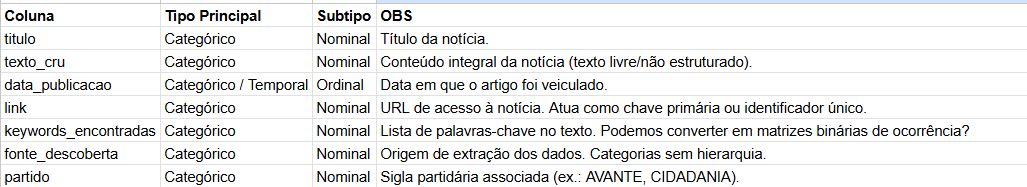

In [8]:
discourse_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  256 non-null    str   
 1   event_id            256 non-null    int64 
 2   deputy_id           256 non-null    int64 
 3   deputy_name         256 non-null    str   
 4   party               256 non-null    str   
 5   political_spectrum  256 non-null    str   
 6   ideological_stance  256 non-null    str   
 7   state               256 non-null    str   
 8   legislature_id      256 non-null    int64 
 9   speech_type         256 non-null    str   
 10  keywords            256 non-null    str   
 11  transcript          256 non-null    str   
 12  summary             256 non-null    str   
 13  start_date          256 non-null    str   
 14  end_date            256 non-null    str   
 15  major_claim         256 non-null    str   
 16  micro_arguments     256 non-null    o

### 1.4. Transformação nos Dados

In [ ]:
def get_argument(adu) -> str:
    parts = [adu["major_claim"]]

    for micro_argument in adu["micro_arguments"]:
        parts.append(micro_argument["claim"])

        for premise in micro_argument["premises"]:
            if premise.strip().upper() == "[IMPLICIT]":
                continue
            parts.append(premise)

    return " ".join(parts)

In [ ]:
discourse_df["argument"] = discourse_df.apply(get_argument, axis=1);
discourse_df["argument"][0]

'O psb também vota a favor do projeto Alertando nossos queridos guardas e agentes penitenciários para a responsabilidade que se deve ter com uma arma na mão e também dentro de casa Pelo risco aos familiares É preciso que quem recebe o porte de arma receba um treinamento sério O psb se preocupa muito com essa questão de termos cada vez mais armas nas ruas É necessário que os próprios agentes de segurança prisional busquem esse treinamento Para que a arma não se volte contra eles e não prejudique a sociedade'

## 2. Análise Exploratória (EDA)


### 2.1. Tamanho do texto em caracteres


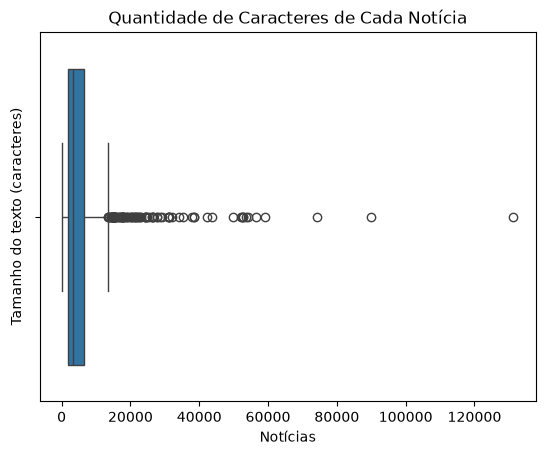

In [11]:
news_size = news_df['texto_cru'].fillna('').str.len()
sns.boxplot(news_df, x = news_size)
plt.title('Quantidade de Caracteres de Cada Notícia')
plt.xlabel("Notícias")
plt.ylabel('Tamanho do texto (caracteres)')
plt.show()

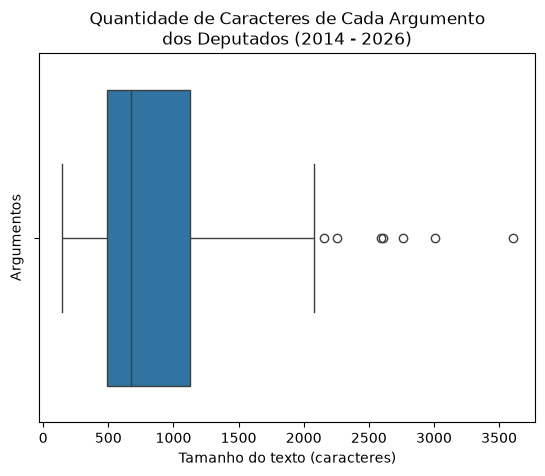

In [12]:
argument_size = discourse_df['argument'].str.len()
sns.boxplot(discourse_df, x = argument_size)
plt.title("Quantidade de Caracteres de Cada Argumento\ndos Deputados (2014 - 2026)")
plt.xlabel("Tamanho do texto (caracteres)")
plt.ylabel("Argumentos")
plt.show()

### 2.2. Palavras-chave mais frequentes

In [13]:
most_frequent_kw_news = news_df['keywords_encontradas'].explode().value_counts()

print('As palavras-chave mais frequentes encontradas nas notícias são:')
print(most_frequent_kw_news.head(10))

As palavras-chave mais frequentes encontradas nas notícias são:
keywords_encontradas
armas                       845
arma                        363
desarmamento                357
armas de fogo               320
porte de armas              234
arma de fogo                213
estatuto do desarmamento    202
armamento                   145
porte de arma                94
municao                      83
Name: count, dtype: int64


In [19]:
most_frequent_kw_discourses = discourse_df["keywords"].explode().value_counts()

print('As palavras-chave mais frequentes que pautam os discursos parlamentares são:')
print(most_frequent_kw_discourses.head(10))

As palavras-chave mais frequentes que pautam os discursos parlamentares são:
keywords
DISCUSSÃO, PL 3723/2019, PROJETO DE LEI ORDINÁRIA, FAVORÁVEL.                                                                                                                    5
DISCUSSÃO, PL 3723/2019, PROJETO DE LEI ORDINÁRIA, CONTRÁRIO.                                                                                                                    4
PL 3723/2019, PROJETO DE LEI ORDINÁRIA, ALTERAÇÃO, ESTATUTO DO DESARMAMENTO, CERTIFICADO DE REGISTRO DE ARMA DE FOGO, POSSE DE ARMA, CONTRÁRIO.                                  4
ORIENTAÇÃO DE BANCADA, REQUERIMENTO DE ADIAMENTO DA VOTAÇÃO, PL 3723/2019, PROJETO DE LEI ORDINÁRIA, PARTIDO SOCIALISMO E LIBERDADE (PSOL), OBSTRUÇÃO PARLAMENTAR.               4
ENCAMINHAMENTO DE VOTAÇÃO, REQUERIMENTO DE ADIAMENTO DA VOTAÇÃO, PL 3723/2019, PROJETO DE LEI ORDINÁRIA, CONTRÁRIO.                                                              4
PL 3723/2019, PROJE

### 2.3. partidos com mais notícias

In [15]:
partidos_noticias = news_df['partido'].value_counts().reset_index()
partidos_noticias.columns = ['partido', 'quantidade_noticias']
print('Partidos com mais notícias:')
print(partidos_noticias.to_string(index=False))

Partidos com mais notícias:
                                partido  quantidade_noticias
           PARTIDO COMUNISTA BRASILEIRO                  137
            PARTIDO COMUNISTA DO BRASIL                  126
PARTIDO DA SOCIAL DEMOCRACIA BRASILEIRA                  126
                          PARTIDO VERDE                   96
          PARTIDO SOCIALISTA BRASILEIRO                   90
                           REPUBLICANOS                   84
         PARTIDO SOCIALISMO E LIBERDADE                   78
              PARTIDO DOS TRABALHADORES                   71
        PARTIDO DEMOCRÁTICO TRABALHISTA                   64
             PARTIDO SOCIAL DEMOCRÁTICO                   62
                           PARTIDO NOVO                   30
                              CIDADANIA                   22
                        PARTIDO LIBERAL                   18
                        UNIDADE POPULAR                   17
       MOVIMENTO DEMOCRÁTICO BRASILEIRO                  

### 3.4 Palavras-chave mais encontradas por partido

*Talvez uma maior preocupação dos partidos de esquerda em veicular os assuntos de armamento?

In [16]:
print('A palavra-chave mais encontrada por partido é:')
keywords_by_party_top1 = news_df.groupby('partido')['keywords_encontradas'].apply(lambda keywords: keywords.explode().value_counts().head(1))

# Converter em visão tabular
keywords_df = keywords_by_party_top1.reset_index()
keywords_df.columns = ['partido', 'palavra_chave', 'contagem']

# Ordenar 'contagem' decrescentemente
keywords_df = keywords_df.sort_values(by='contagem', ascending=False)
print(keywords_df.to_string(index=False))

A palavra-chave mais encontrada por partido é:
                                partido palavra_chave  contagem
           PARTIDO COMUNISTA BRASILEIRO         armas       110
            PARTIDO COMUNISTA DO BRASIL         armas       105
PARTIDO DA SOCIAL DEMOCRACIA BRASILEIRA         armas        89
          PARTIDO SOCIALISTA BRASILEIRO         armas        81
                          PARTIDO VERDE         armas        70
                           REPUBLICANOS         armas        67
         PARTIDO SOCIALISMO E LIBERDADE         armas        66
              PARTIDO DOS TRABALHADORES         armas        57
        PARTIDO DEMOCRÁTICO TRABALHISTA         armas        55
             PARTIDO SOCIAL DEMOCRÁTICO         armas        45
                           PARTIDO NOVO         armas        26
                              CIDADANIA         armas        22
       MOVIMENTO DEMOCRÁTICO BRASILEIRO         armas        13
                        PARTIDO LIBERAL         armas    

### 3.5 Ano com mais notícias

*2019 foi o primiero ano do Governo de Jair Bolsonaro e forte eleição de parlamentares a favor de armamento civil.

In [17]:
news_df['ano_publicacao'] = pd.to_datetime(news_df['data_publicacao']).dt.year
print('Quantidade de notícias por ano:')
news_df['ano_publicacao'].value_counts()

Quantidade de notícias por ano:


ano_publicacao
2019    152
2025    133
2026    119
2024    107
2022     83
2021     60
2023     56
2020     46
2018     43
2016     43
2015     36
2017     33
2010     29
2007     19
2012     18
2014     15
2011     13
2009     12
2013     12
2003      9
2005      8
2006      7
2008      4
2004      3
2001      1
Name: count, dtype: int64

### 3.6 Data com mais notícias

*Em 29-05-2024 o Congresso Nacional derrubou o veto do presidente à restrição do benefício da saída temporária de presos.

*Em 11-01-2025 o congresso tratou de temas relacionados à PEC da segurança pública.

In [18]:
news_df['data_publicacao'].value_counts(dropna=False).head(10)

data_publicacao
2024-05-29    34
2025-01-11    12
2019-06-19     5
2018-08-29     5
2022-09-06     5
2016-03-14     5
2019-01-15     5
2019-06-03     4
2025-11-17     4
2025-12-09     4
Name: count, dtype: int64